In [9]:
######################################################
# IMPORTS — Notebook Machine Learning / Classification
######################################################

# ====================================================
# Gestion des avertissements
# ====================================================

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# ====================================================
# Librairies standards Python
# ====================================================

import os
import time
from pathlib import Path
from typing import Dict

# ====================================================
# Calcul scientifique & manipulation de données
# ====================================================

import numpy as np
import pandas as pd
from numpy.typing import NDArray

# ====================================================
# Visualisation
# ====================================================

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ====================================================
# Scikit-learn — Jeux de données
# ====================================================

from sklearn.datasets import (
    load_breast_cancer,
    load_digits,
    load_iris,
    make_classification,
    make_multilabel_classification,
)

# ====================================================
# Scikit-learn — Prétraitement
# ====================================================

from sklearn.preprocessing import (
    StandardScaler,
    label_binarize,
)

# ====================================================
# Scikit-learn — Réduction de dimension
# ====================================================

from sklearn.decomposition import PCA

# ====================================================
# Scikit-learn — Séparation des données
# ====================================================

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    GridSearchCV,
)

# ====================================================
# Scikit-learn — Modèles de classification
# ====================================================

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# ====================================================
# Scikit-learn — Évaluation des modèles
# ====================================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

# ====================================================
# Scikit-learn — Feature engineering & interprétabilité
# ====================================================

from sklearn.feature_selection import f_classif
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_class_weight

# ====================================================
# Scikit-learn — Pipeline
# ====================================================

from sklearn.pipeline import Pipeline

# ====================================================
# Optimisation d'hyperparamètres
# ====================================================

import optuna

# ====================================================
# Sauvegarde / chargement de modèles
# ====================================================

import joblib

# ====================================================
# Imports personnalisés du projet
# ====================================================

from code_python.recherche_classifieur.data_projet import (
    create_model,
    get_param,
)

from code_python.recherche_classifieur.get_df import (
    split_train_test,
    split_x_y,
)

from code_python.recherche_classifieur.visualisation import (
    plot_confusion_matrix,
)

1. Récupération des données

In [10]:
######################################################
# Chargement du jeu de données
######################################################
colonne_y = 'science_related'


def get_data_from_csv():
    ROOT = Path().resolve().parent.parent # chemin du fichier actuel
    name = input("nom de la matrice : ") + ".csv"
    csv_path = ROOT / "matrices" / name


    # Charger le dataset (séparateur: point-virgule)
    df = pd.read_csv(csv_path, sep=';')

    print("------ Chargement du dataset depuis :", csv_path)
    print(df.head())
    print(df.shape)
    return df

def get_pipeline(path_joblib=None):
    ROOT = Path().resolve() / "src"

    if path_joblib is None:
        name = input("nom de la pipeline : ")+".joblib"
        pipeline_path = ROOT / "pipelines" / name
    else:
        pipeline_path = path_joblib
    pipe = joblib.load(pipeline_path)

    return pipe
######################################################
# Séparation des données d'apprentissage et de classification + entrainement vs test
######################################################
def split_train_test(df) -> tuple:
    y = df[colonne_y]
    X = df.drop(columns=['scientific_context','scientific_reference','scientific_claim',colonne_y,'tweet_id'], errors='ignore')

    print(X.shape)
    print(y.shape)

    # Séparation du jeu de données (70/30 )
    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
    
    print(f"format du jeu d'apprentissage : {x_train.shape}")
    print(f"format du jeu de test : {x_test.shape}")
    return (X, y, x_train, y_train, x_test, y_test)

def split_x_y(df, target=colonne_y) -> tuple:
    y = df[target]
        
    cols_to_drop = [
        "science_related",
        "scientific_claim",
        "scientific_reference",
        "scientific_context",
        "tweet_id",
    ]

    if target not in cols_to_drop:
        cols_to_drop.append(target)

    # Au cas où dict from keys pour pas avoir de double
    X = df.drop(columns=list(dict.fromkeys(cols_to_drop)), errors="ignore")

    return X, y

2. Définir les données du projet

In [11]:
def get_priors(y_train) -> list:
    # 1. Calcul des poids (ex: [0.52, 10.4])
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)

    # 2. Normalisation pour que la somme soit égale à 1
    # On divise chaque poids par la somme totale des poids
    priors_normalized = weights / weights.sum()

    return priors_normalized


def get_dico_classifieur(y_train, use_class_weight:bool=False) -> dict:
    result = {}
    # à décommenter uniquement pour faire les tests plus vite
    return{"SVC":SVC()}


    if use_class_weight:
        result = {"KNN":KNeighborsClassifier(weights="distance"),   # n"a pas de class_weight
            "DT":DecisionTreeClassifier(class_weight="balanced"),
            "GNB":GaussianNB(priors = get_priors(y_train)), # n"a pas de class_weight
            "SVC":SVC(class_weight="balanced"),
            "RF":RandomForestClassifier(class_weight="balanced"),
            "LR":LogisticRegression(class_weight="balanced")}
    
    else :
        result = {"KNN":KNeighborsClassifier(),   # n"a pas de class_weight
                "DT":DecisionTreeClassifier(),
                "GNB":GaussianNB(), # n"a pas de class_weight
                "SVC":SVC(),
                "RF":RandomForestClassifier(),
                "LR":LogisticRegression()}
        
    return result

def create_model(classifier_name, params={}):
    """Fonction utilitaire pour centraliser la création des modèles."""
    if classifier_name == "RF":
        return RandomForestClassifier(**params, random_state=42)
    elif classifier_name == "DT":
        return DecisionTreeClassifier(**params, random_state=42)
    elif classifier_name == "SVC":
        return SVC(**params)
    elif classifier_name == "KNN":
        return KNeighborsClassifier(**params)
    elif classifier_name == "GNB":
        return GaussianNB(**params)
    elif classifier_name == "LR":
        return LogisticRegression(**params)
    raise ValueError(f"Classifieur {classifier_name} non supporté.")

def get_param(classifier_name):
    RF_param = {
        "n_estimators": [4, 6, 9],
        "max_features": ["log2", "sqrt"],
        "criterion": ["entropy", "gini"],
        "max_depth": [2, 3, 5, 10],
        "min_samples_split": [2, 3, 5],
        "min_samples_leaf": [1, 5, 8]   
    }
    DT_param = {
        "max_depth": [1,2,3,4,5,6,7,8,9,10],
        "criterion": ["gini", "entropy"],
        "min_samples_leaf": [1,2,3,4,5,6,7,8,9,10]
    }
    # https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
    svc_param = {
        "C": [0.001, 0.01, 0.1, 0.4, 0.8, 1, 1.1, 1.2, 1.3, 1.4, 3, 6, 6.5, 6.8, 7, 7.3, 7.5, 7.6, 7.7, 7.8, 7.9, 8, 8.1, 8.2, 8.3, 8.4, 8.5, 9, 10, 11, 12, 13, 15, 20],
        "gamma": [0.00005, 0.00008, 0.001, 0.002, 0.005, 0.01, 0.1, 1, 2, 5, 7, 10, "scale"],
        "kernel": ["linear", "poly", "rbf"],
        "degree":[2,3,4,5],     # uniquement pour le kernel poly
        "class_weight": ["balanced", None]
    }

    #     svc_param = {
    #    "C": [0.001, 0.01, 0.1, 0.4, 0.8, 1, 1.1, 1.2, 1.3, 1.4, 10],
    #    "gamma": [0.00005, 0.00008, 0.001, 0.002, 0.005, 0.01, 0.1, 1, 2, 5, 7, 10, "scale"],
    #    "kernel": ["linear", "poly", "rbf"],
    #    "degree":[2,3,4,5],     # uniquement pour le kernel poly
    #    "class_weight": ["balanced", None]
    #}
    

    KNN_param = {
        "n_neighbors": [3, 5, 7, 11, 15],
        "weights": ["uniform", "distance"],
        "algorithm": ["auto", "ball_tree", "kd_tree"]
        }
    GNB_param= {
        "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6] # Le seul paramètre réel de GNB
        }
    nb_param = {
        "alpha" : [0.1 , 0.5, 1.0]
    }
    logistic_param = {
        "C" : [0.1, 1, 10]
    }

    hyper_param = {
        "KNN": KNN_param,
        "DT": DT_param,
        "GNB": GNB_param,
        "SVC": svc_param,
        "RF": RF_param,
        "LR" : logistic_param
        #"NB" : nb_param
    }

    return hyper_param[classifier_name]


3. Visualisation des données

In [12]:
""""
Notebook_EvaluationModeles.pdf

citation sujet ML : 
N oubliez pas de bien évaluer vos modèles. L accuracy n est pas suffisante. Pensez à la matrice
de confusion, au rappel, à la précision, à la F-mesure

matric conf : ok
rappel : ok
precision : ok
f mesure : ok

je ne comprends pas à quoi sert la courbe roc page 21 - plot_roc_curve
je crois que c'est pour l'analyse under/over fitting. Il faudra effectivement ajouter cette analyse
"""


def boite_a_moustache(results: Dict[str, NDArray[np.float64]]) -> None:
    fig = plt.figure()
    fig.suptitle("Comparaison des algorithmes")
    ax = fig.add_subplot(111)
    
    plt.boxplot(list(results.values()))
    
    # Pour les labels, c'est pareil : on convertit en liste
    ax.set_xticklabels(list(results.keys()))
    
    plt.show()

def plot_class_distribution(y, class_names=None):
    """
    Affiche la répartition des classes et génère un histogramme.
    Paramètres :
    - y : array-like
    Labels des classes (int ou str).
    - class_names : list, optional
    Noms des classes pour l'axe des x (default: None,
    utilise les valeurs uniques de y).
    """
    # Calculer la répartition des classes
    unique, counts = np.unique(y, return_counts=True)
    print("Répartition des classes :")
    for cls, count in zip(unique, counts):
        print(f"Classe {cls} : {count} échantillons")
    
    # Si aucun nom de classe n'est fourni, utiliser les valeurs uniques de y
    if class_names is None:
        class_names = [f"Classe {cls}" for cls in unique]
    
    # Histogramme de la répartition des classes
    plt.figure(figsize=(6, 4))
    plt.bar(unique, counts, color=['blue', 'orange'], alpha=0.7)
    plt.xticks(unique, class_names)
    plt.ylabel("Nombre d'échantillons")
    plt.title("Répartition des classes")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


def plot_confusion_matrix(conf_matrix, title="Matrice de confusion", labels=None, cmap="Blues"):
    """
    Trace une matrice de confusion sous forme de heatmap.
    Paramètres :
    - conf_matrix : array-like (2D)
    Matrice de confusion .
    - title : str, optional
    Titre du graphique (default : "Matrice de confusion").
    - labels : list, optional
    Liste des noms des classes pour les axes
    (default : None, utilise les indices numériques).
    - cmap : str, optional
    Colormap pour la heatmap (default : "Blues").
    """
    # Générer des labels par défaut si non spécifiés
    if labels is None:
        labels = [f"Classe {i}" for i in range(conf_matrix.shape[0])]
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap=cmap,
    xticklabels=labels, yticklabels=labels)
    
    plt.title(title)
    plt.ylabel("Classe Réelle")
    plt.xlabel("Classe Prédite")
    plt.tight_layout()
    plt.show()

    
def plot_roc_curve(fpr, tpr, auc_score):
    """
    Trace la courbe ROC (Receiver Operating Characteristic)
    pour évaluer la performance d'un modèle de classification.
    Paramètres :
    - fpr : array-like
    Taux de faux positifs (False Positive Rate) pour différents seuils.
    - tpr : array-like
    Taux de vrais positifs (True Positive Rate) pour différents seuils.
    - auc_score : float
    Aire sous la courbe ROC (Area Under the Curve, AUC),
    une mesure globale de performance.
    Fonctionnalités :
    - Trace la courbe ROC avec la courbe réelle en bleu.
    - Ajoute une diagonale en rouge indiquant la ligne de référence pour
    un modèle aléatoire.
    - Affiche l'AUC dans la légende.
    ```
    """
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--') # Diagonale
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.4)
    plt.show()


def plot_pca_2d_3d(X, y, title_2d="ACP 2D", title_3d="ACP 3D"):
    """
    Affiche une ACP 2D et 3D pour visualiser la répartition des documents.
    X : matrice de features (numpy array ou matrice creuse)
    y : labels (array-like)
    """
    # Conversion si matrice creuse
    X_dense = X.toarray() if hasattr(X, "toarray") else X
    y = np.array(y)
    # ACP 2D
    pca_2d = PCA(n_components=2, random_state=0)
    X_pca_2d = pca_2d.fit_transform(X_dense)
    # ACP 3D
    pca_3d = PCA(n_components=3, random_state=0)
    X_pca_3d = pca_3d.fit_transform(X_dense)
    # Figure
    fig = plt.figure(figsize=(12, 5))
    # ----- Plot 2D -----
    ax1 = fig.add_subplot(1, 2, 1)
    idx0 = (y == 0)
    idx1 = (y == 1)
    ax1.scatter(X_pca_2d[idx0, 0], X_pca_2d[idx0, 1], alpha=0.6, label="Not science related")
    ax1.scatter(X_pca_2d[idx1, 0], X_pca_2d[idx1, 1], alpha=0.6, label="Science related")
    ax1.set_title(title_2d)
    ax1.set_xlabel("PC1")
    ax1.set_ylabel("PC2")
    ax1.legend()
    # ----- Plot 3D -----
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    ax2.scatter(X_pca_3d[idx0, 0], X_pca_3d[idx0, 1], X_pca_3d[idx0, 2], alpha=0.6, label="Not science related")
    ax2.scatter(X_pca_3d[idx1, 0], X_pca_3d[idx1, 1], X_pca_3d[idx1, 2], alpha=0.6, label="Science related")
    ax2.set_title(title_3d)
    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")
    ax2.set_zlabel("PC3")
    plt.tight_layout()
    plt.show()

def word_cloud(df):
    # 1. On exclut les colonnes qui ne sont pas des mots
    cols_to_drop = ['scientific_context', 'scientific_reference', 'scientific_claim', 'science_related', 'tweet_id']
    df_words = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    
    # 2. On additionne les occurrences et on remplace les espaces par des "_"
    word_counts_brut = df_words.sum().to_dict()
    
    # Création d'un nouveau dictionnaire avec les clés modifiées
    word_counts = {mot.replace(' ', '_'): frequence for mot, frequence in word_counts_brut.items()}
    
    # 3. Création du word cloud
    wc = WordCloud(
        width=800, 
        height=400, 
        background_color="white",
        prefer_horizontal=0.7,      
        relative_scaling=0.5,       
        max_words=200,              
        min_font_size=10,           
        max_font_size=150           
    )
    wc.generate_from_frequencies(word_counts) # Génération basée sur le dictionnaire de fréquences
    
    # 4. Affichage
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()
    
    # (Optionnel) Sauvegarde de l'image
    wc.to_file("wordcloud.png")
    # 1. On exclut les colonnes qui ne sont pas des mots
    cols_to_drop = ['scientific_context', 'scientific_reference', 'scientific_claim', 'science_related', 'tweet_id']
    df_words = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    
    # 2. On additionne les occurrences de chaque colonne/mot sur tout le dataset
    word_counts = df_words.sum().to_dict()
    
    # 3. Création du word cloud
        # 3. Création du word cloud
    wc = WordCloud(
        width=800, 
        height=400, 
        background_color="white",
        prefer_horizontal=0.7,      # Autorise 30% des mots à être placés à la verticale (imbrication)
        relative_scaling=0.5,       # Accentue la différence de taille entre les mots fréquents et rares
        max_words=200,              # Limite le nombre de mots pour éviter l'effet "bloc"
        min_font_size=10,           # Taille minimum
        max_font_size=150           # Taille maximum très grande pour les gros mots
    )
    wc.generate_from_frequencies(word_counts) # Génération basée sur le dictionnaire de fréquences
    
    # 4. Affichage
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()
    
    # (Optionnel) Sauvegarde de l'image
    wc.to_file("wordcloud.png")

def data_2d_3d_visu(df):

    column_principal = "science_related"

    # Colonnes numériques utilisées pour l'ACP
    cols_for_pca = [
        "scientific_context","scientific_reference","scientific_claim"
    ]

    X_pca = df[cols_for_pca].values

    # Standardisation
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_pca)

    # ACP sur 3 composantes
    pca = PCA(n_components=3)
    X_pca_3d = pca.fit_transform(X_scaled)

    df_pca = pd.DataFrame({
        "PC1": X_pca_3d[:, 0],
        "PC2": X_pca_3d[:, 1],
        "PC3": X_pca_3d[:, 2],
        "science_related": df[column_principal]
    })

    fig = make_subplots(
        rows=1,
        cols=2,
        specs=[[{"type": "xy"}, {"type": "scene"}]],
        subplot_titles=(
            "Projection 2D (PC1, PC2)",
            "Projection 3D (PC1, PC2, PC3)"
        )
    )

    # Scatter 2D à gauche
    fig.add_trace(
        go.Scatter(
            x=df_pca["PC1"],
            y=df_pca["PC2"],
            mode="markers",
            marker=dict(
                color=df_pca[column_principal],
                colorscale="Viridis",
                showscale=True,
                colorbar=dict(title=column_principal)
            ),
            name="2D"
        ),
        row=1,
        col=1
    )

    fig.update_xaxes(title_text="PC1", row=1, col=1)
    fig.update_yaxes(title_text="PC2", row=1, col=1)

    # Scatter 3D à droite
    fig.add_trace(
        go.Scatter3d(
            x=df_pca["PC1"],
            y=df_pca["PC2"],
            z=df_pca["PC3"],
            mode="markers",
            marker=dict(
                size=4,
                color=df_pca[column_principal],
                colorscale="Viridis",
                showscale=False
            ),
            name="3D"
        ),
        row=1,
        col=2
    )

    fig.update_scenes(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3",
        row=1,
        col=2
    )

    fig.update_layout(
        title="ACP des données de Tweet (2D et 3D)",
        width=900,
        height=450
    )

    fig.show()


4. Evaluation des classifieurs

------ Chargement du dataset depuis : D:\mes programmes python\HAI817I-Machine-learning-m-thodes-classiques\src\matrices\1mot.csv
   scientific_context  scientific_reference  scientific_claim  \
0                 0.0                   0.0               0.0   
1                 0.0                   0.0               0.0   
2                 0.0                   0.0               1.0   
3                 0.0                   0.0               1.0   
4                 0.0                   0.0               1.0   

   science_related            tweet_id  1st  4th  ability  able  abortion  \
0                0  316669998137483264  0.0  0.0      0.0   0.0       0.0   
1                0  319090866545385472  0.0  0.0      0.0   0.0       0.0   
2                1  322030931022065664  0.0  0.0      0.0   0.0       0.0   
3                1  322694830620807168  0.0  0.0      0.0   0.0       0.0   
4                1  328524426658328576  0.0  0.0      0.0   0.0       0.0   

   ...  worthy  

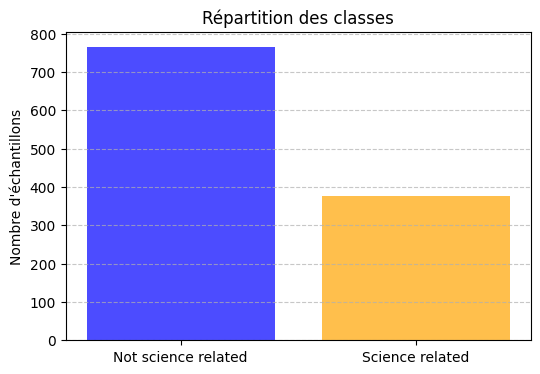

KFold sur SVC : accuracy moyenne : 0.7442721518987343 écart-type : 0.03391497198092948
Accuracy : 0.7660818713450293
Matrice de confusion
[[225   5]
 [ 75  37]]


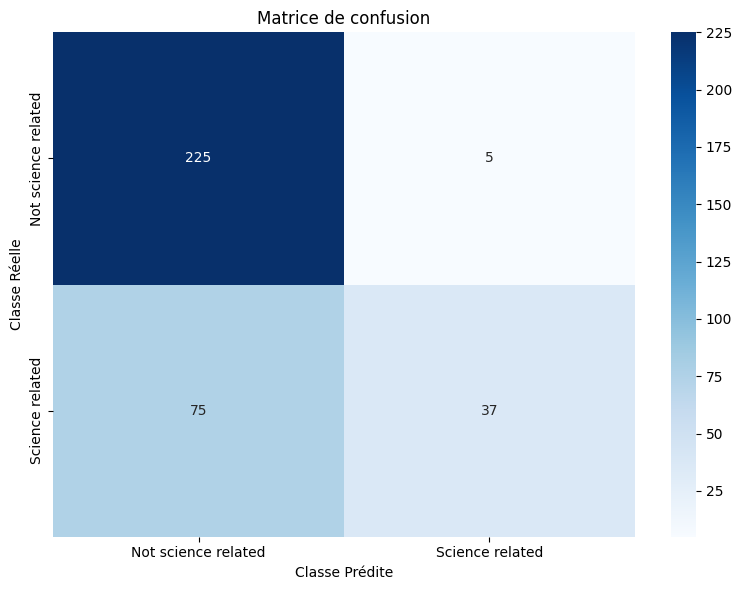

Classification report
              precision    recall  f1-score   support

           0       0.75      0.98      0.85       230
           1       0.88      0.33      0.48       112

    accuracy                           0.77       342
   macro avg       0.82      0.65      0.66       342
weighted avg       0.79      0.77      0.73       342



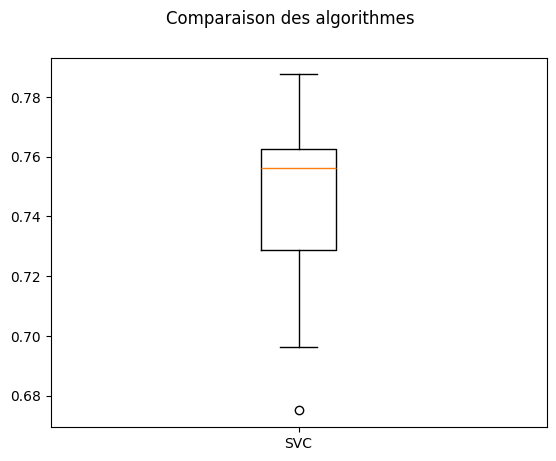

In [ ]:
def get_scores_classifieurs(x_train, y_train, x_test, y_test, dico_classifieur) -> dict:
    # Utilisation de plusieurs Classifieurs sur le même jeu de données (KNN, DT, GAUSSIAN , SVC, RF)

    cv = KFold(n_splits=10, shuffle=True, random_state=0)

    results = {}

    for name, clf in dico_classifieur.items():
        scores = cross_val_score(clf, x_train, y_train, cv=cv, scoring='accuracy')
        results[name] = scores
        print(f"KFold sur {name} : accuracy moyenne : {scores.mean()} écart-type : {scores.std()}")

        clf.fit(x_train, y_train)
        y_pred = clf.predict(x_test)

        print(f"Accuracy : {accuracy_score(y_test, y_pred)}")

        # Matrice de confusion
        conf_matrix = confusion_matrix(y_test, y_pred)
        print(f"Matrice de confusion\n{conf_matrix}")
        
        plot_confusion_matrix(conf_matrix, title="Matrice de confusion", labels=["Not science related", "Science related"], cmap="Blues")


        # classification report
        class_report = classification_report(y_test, y_pred, zero_division=0)
        print(f"Classification report\n{class_report}")

    return results

# Le découpage Train/Test est effecuté directement par Aurélie et Romane en amont. Il y'a une matrice te(st) et une tr(ain)
df = get_data_from_csv()    # récupération des données et stockage dans un DataFrame
X, y, x_train, y_train, x_test, y_test = split_train_test(df)   # Séparation des données entre données d'entrainement, résultat à prédire, et données de test
plot_class_distribution(y, class_names=['Not science related', 'Science related'])

dico_classifieur = get_dico_classifieur(y_train=y_train, use_class_weight=False)    # je suis pas hyper sur de ceci, parce que pour GNB prend la proportion des classes de y_train en entier, alors qu'après on teste des échantillons plus petits
dico_classifieur = get_scores_classifieurs(x_train, y_train, x_test, y_test, dico_classifieur)    # Evaluation de chaque classifieur en attribuant un score

boite_a_moustache(dico_classifieur)    # Visualisation des résultats obtenus pour chaque classifieur

name_selected = input("Quel classifieur choisissez-vous\n:")
found = False
while not found:
    if name_selected not in dico_classifieur.keys():
        print(f"Classifieurs possibles : {dico_classifieur.keys()}")
        name_selected = input("Nom incorrect : Quel classifieur choisissez-vous\n:")
    else:
        found = True

5. Recherche des meilleurs hyperparam

In [14]:

def get_best_params(classifier_name, x_train, y_train, x_test, y_test):
    # appel de la fonction GridSearchCV
    # get_best_params_GridSearchCV(classifier_name, x_train, y_train)
    # Adri2 : GridSearchCV est TRES long et fonctionne par combinaison "aveugle" de tous les hyperparam. Optuna est plus pertinent et plus rapide. On se passera de GridSearchCV pour les tests
    # appel de la fonction Optuna
    best_modele_best_param = get_best_params_optuna(classifier_name, x_train, y_train, x_test, y_test)

    return best_modele_best_param

def get_best_params_GridSearchCV(classifier_name, x_train, y_train):  
    # Affichage du meilleur score + paramètres associés 
    print("--------------------------- GridSearchCV ---------------------------\n\n")

    modele = create_model(classifier_name)
    print("modele créé")

    params_config = get_param(classifier_name)
    if params_config is None:
        print("pas de params")
        raise ValueError(f"Config pour {classifier_name} non trouvée.")
    
    
    search = GridSearchCV(modele, params_config, cv=5)
    print("GridSearchCV créé")
    search.fit(x_train, y_train)
    
    print(f"Meilleur score : {search.best_score_}")
    print(f"Meilleurs paramètres : {search.best_params_}")
    print(f"Meilleur estimateur : {search.best_estimator_}")
    return search.best_params_

# Utilisation de Optuna pour automatiser la recherhe des meilleurs hyperparamètres 
def objective(trial, classifier_name, X, y):
    """Fonction objectif pour Optuna qui évalue un classifieur donné avec des hyperparamètres suggérés."""
        
    # Récupérer la config du classifieur
    params_config = get_param(classifier_name)
        
    if params_config is None:
        raise ValueError(f"Config pour {classifier_name} non trouvée.")
    
    # Demander à Optuna de choisir une valeur dans chaque liste
    chosen_params = {}
    for param_name, values in params_config.items():
        chosen_params[param_name] = trial.suggest_categorical(param_name, values)


    # Instancier le bon modèle avec les paramètres choisis
    model = create_model(classifier_name, chosen_params)

    # Évaluation
    score = cross_val_score(model, X, y, cv=5, n_jobs=-1).mean()
    return score

def get_best_params_optuna(classifier_name, X_train, y_train, X_test, y_test):
    """ Fonction pour lancer l'optimisation avec Optuna et évaluer le meilleur modèle sur le set test."""
    print("--------------------------- Optuna ---------------------------\n\n")
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(trial, classifier_name, X_train, y_train), n_trials=50)

    print(f"Meilleur score pour {classifier_name} :", round(study.best_value, 3))
    print(f"Meilleurs paramètres pour {classifier_name} :", study.best_params)

    # reconstruction du meilleur modèle pour prédiction finale
    best_params = study.best_params

    best_model = create_model(classifier_name, best_params)   

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    print(f"Accuracy : {accuracy_score(y_test, y_pred)}")

    # Matrice de confusion
    conf_matrix = confusion_matrix(y_test, y_pred)
    print(f"Matrice de confusion\n{conf_matrix}")
    # classification report
    class_report = classification_report(y_test, y_pred, zero_division=0)
    print(f"Classification report\n{class_report}")
    
    plot_confusion_matrix(conf_matrix, title="Matrice de confusion", labels=["Not science related", "Science related"], cmap="Blues")

    print(f"Accuracy  sur le jeu de test : {round(accuracy_score(y_test, y_pred),3)}")
    return best_params




[I 2026-05-12 16:07:06,399] A new study created in memory with name: no-name-ad3528be-4c8d-4797-b87b-6533849ad420


--------------------------- Optuna ---------------------------




[I 2026-05-12 16:07:16,276] Trial 0 finished with value: 0.6704323899371069 and parameters: {'C': 13, 'gamma': 0.005, 'kernel': 'poly', 'degree': 3, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6704323899371069.
[I 2026-05-12 16:07:18,337] Trial 1 finished with value: 0.6704323899371069 and parameters: {'C': 13, 'gamma': 0.002, 'kernel': 'poly', 'degree': 3, 'class_weight': None}. Best is trial 0 with value: 0.6704323899371069.
[I 2026-05-12 16:07:21,082] Trial 2 finished with value: 0.5320676100628929 and parameters: {'C': 10, 'gamma': 5e-05, 'kernel': 'poly', 'degree': 2, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6704323899371069.
[I 2026-05-12 16:07:23,773] Trial 3 finished with value: 0.6741981132075472 and parameters: {'C': 1.3, 'gamma': 5, 'kernel': 'rbf', 'degree': 2, 'class_weight': 'balanced'}. Best is trial 3 with value: 0.6741981132075472.
[I 2026-05-12 16:07:26,375] Trial 4 finished with value: 0.6116981132075472 and parameters: {'C': 7.9, 'ga

Meilleur score pour SVC : 0.783
Meilleurs paramètres pour SVC : {'C': 1.3, 'gamma': 5, 'kernel': 'linear', 'degree': 2, 'class_weight': 'balanced'}
Accuracy : 0.7807017543859649
Matrice de confusion
[[189  41]
 [ 34  78]]
Classification report
              precision    recall  f1-score   support

           0       0.85      0.82      0.83       230
           1       0.66      0.70      0.68       112

    accuracy                           0.78       342
   macro avg       0.75      0.76      0.75       342
weighted avg       0.78      0.78      0.78       342



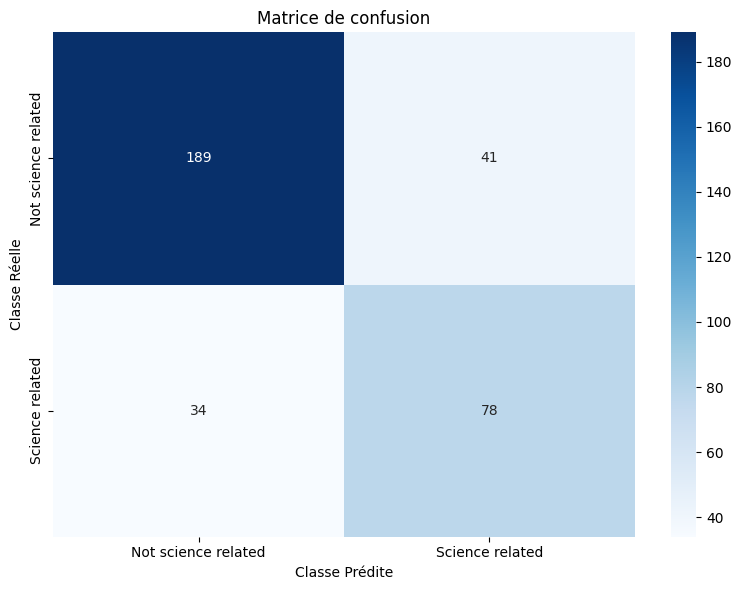

Accuracy  sur le jeu de test : 0.781


In [15]:
plt.close('all')    # vide la mémoire
result = get_best_params(name_selected, x_train, y_train, x_test, y_test)

6. Mise en production

In [16]:

def save_model(df, classifier_name, best_params):
    print("###################################\n# SAUVEGARDE\n###################################")
    ROOT = Path().resolve().parent.parent # chemin du fichier actuel
    name = input("nom de la pipeline : ")+".joblib"
    pipeline_path = ROOT  / "pipelines" / name

    df2 = df.sample(n=4)
    df = df.drop(df2.index)

    df2.head()

    X, y, X_train, y_train, X_test, y_test = split_train_test(df)   # Séparation des données entre données d'entrainement, résultat à prédire, et données de test

    # Classifieur final (à adapter si besoin selon vos propres résultats)
    final_clf = create_model(classifier_name, best_params)
    print("model créé")

    # Pipeline minimal contenant le classifieur
    pipeline_final = Pipeline([
        ("clf", final_clf)
    ])
    print("pipeline créée")
    print(best_params)

    # Entraînement du pipeline sur toutes les données disponibles
    pipeline_final.fit(X, y)
    print("modèle entrainée")

    # Sauvegarde du pipeline
    joblib.dump(pipeline_final, pipeline_path)
    print("pipeline saved")
    print(f"Le modèle sera sauvegardé ici : {os.getcwd()}")


    # test sur les 4 données mises de cotées
    # Rechargement du modèle
    loaded_model = joblib.load(pipeline_path)
    print("modèle chargée")

    X, y = split_x_y(df2)   # Séparation des données entre données d'entrainement, résultat à prédire, et données de test


    # Prédictions
    y_pred = loaded_model.predict(X)
    print("prediction réalisée")

    # Affichage clair et simple
    resultats = df2.copy()
    resultats['prediction'] = y_pred
    resultats['reel'] = y
    
    print("Résultat du pipeline sur les données isolées :")
    print(resultats[['reel', 'prediction']])

In [17]:
save_model(df, name_selected, result)

###################################
# SAUVEGARDE
###################################
(1136, 1464)
(1136,)
format du jeu d'apprentissage : (795, 1464)
format du jeu de test : (341, 1464)
model créé
pipeline créée
{'C': 1.3, 'gamma': 5, 'kernel': 'linear', 'degree': 2, 'class_weight': 'balanced'}
modèle entrainée
pipeline saved
Le modèle sera sauvegardé ici : d:\mes programmes python\HAI817I-Machine-learning-m-thodes-classiques\src\code_python\recherche_classifieur
modèle chargée
prediction réalisée
Résultat du pipeline sur les données isolées :
      reel  prediction
507      0           0
552      0           0
952      0           0
1083     0           1


7. Bonus, features discriminantes

In [19]:
# Le but est de récupérer les features (données qui contribuent à la classification) de nos modèles
# Pour ça on va récupéré le df et le x y (grace à la target)


def ranked_features_from_model(model, X_train,y_train, X_val, y_val):
    # Cas 1: modèles avec feature_importances_ (RF, DT...)
    if hasattr(model, "feature_importances_"):
        scores = model.feature_importances_

    # Cas 2: modèles linéaires avec coef_ (LR, SVC kernel='linear')
    elif hasattr(model, "coef_"):
        coef = model.coef_
        scores = np.mean(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef)

    # Cas 3: fallback universel (SVC rbf, KNN, GNB...)
    else:
        print("SVC non linéaire détecté : Utilisation de l'ANOVA (f_classif) pour estimer l'importance des variables instantanément.")
        
        # f_classif calcule un score statistique de pertinence pour chaque colonne
        f_values, p_values = f_classif(X_train, y_train)
        
        # On remplace les potentiels NaN par 0
        scores = np.nan_to_num(f_values, 0)

    ranking = (
        pd.DataFrame({"feature": X_train.columns, "score": scores})
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )
    return ranking


def load_pipeline_and_get_estimator(path_joblib):
    start = time.perf_counter()
    print(f"Chargement du modèle: {path_joblib}")
    pipe = joblib.load(path_joblib)
    print(f"Modèle chargé en {time.perf_counter() - start:.2f}s")

    # Pour récupérer le pipeline est Pipeline([("clf", final_clf)])
    if hasattr(pipe, "named_steps") and "clf" in pipe.named_steps:
        return pipe.named_steps["clf"]

    return pipe


def feature_ranking_for_task(df, target_col, model_path):
    X, y = split_x_y(df, target_col)

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )

    print(f"Target: {target_col} | X_train: {X_train.shape} | X_val: {X_val.shape}")

    model = load_pipeline_and_get_estimator(model_path)
    print(f"Modèle utilisé: {type(model).__name__}")

    start_fit = time.perf_counter()
    model.fit(X_train, y_train)
    print(f"Fit terminé en {time.perf_counter() - start_fit:.2f}s")

    start_rank = time.perf_counter()
    ranking = ranked_features_from_model(model, X_train, y_train, X_val, y_val)
    print(f"Ranking terminé en {time.perf_counter() - start_rank:.2f}s")
    return ranking


# fonction de test pour print et récupérer le modèle de classification
def print_test_pipe_classe():
    df = get_data_from_csv()
    pipe = get_pipeline()
    if hasattr(pipe, "named_steps") and "clf" in pipe.named_steps:
        pipe = pipe.named_steps["clf"]

    print("Type Python:", type(pipe))
    print("Nom classifieur:", type(pipe).__name__)
    print("Classe complète:", pipe.__class__)


if __name__ == "__main__":
    df = get_data_from_csv()

    tasks = ["science_related"]  # ajoute "scientific_claim", "scientific_reference", etc.
    model_path = str(Path(__file__).resolve().parent.parent.parent / "pipelines" / "SMOTE_SVC_meilleurHyperParam.joblib")

    print(f"Dataset chargé: {df.shape}")
    print(f"Modèle chargé depuis: {model_path}")

    for t in tasks:
        r = feature_ranking_for_task(df, t, model_path)
        print(f"\nTop 20 pour {t}")
        print(r.head(20).to_string(index=False))

        r.to_csv(f"top_features_{t}.csv", index=False)
        print(f"Fichier généré: top_features_{t}.csv")

------ Chargement du dataset depuis : D:\mes programmes python\HAI817I-Machine-learning-m-thodes-classiques\src\matrices\baseSMOTE.csv
   USER  USER USER  USER cause  USER good  USER help  USER need  USER report  \
0   0.0        0.0         0.0        0.0        0.0        0.0          0.0   
1   0.0        0.0         0.0        0.0        0.0        0.0          0.0   
2   0.0        0.0         0.0        0.0        0.0        0.0          0.0   
3   0.0        0.0         0.0        0.0        0.0        0.0          0.0   
4   0.0        0.0         0.0        0.0        0.0        0.0          0.0   

   USER stop  USER support  USER url  ...  word      work  world  world url  \
0        0.0           0.0       0.0  ...   0.0  0.423013    0.0        0.0   
1        0.0           0.0       0.0  ...   0.0  0.000000    0.0        0.0   
2        0.0           0.0       0.0  ...   0.0  0.000000    0.0        0.0   
3        0.0           0.0       0.0  ...   0.0  0.000000    0.0    

NameError: name '__file__' is not defined